# FHI — Expert Optimization v3
## Target: Macro F1 ≥ 0.92 on leaderboard

### Key improvements over v2
| Change | Reason |
|--------|--------|
| CatBoost Optuna (50 trials) + class weight search | Was never tuned; adds real diversity |
| Softmax ensemble weights | Prevents v2 collapse to single model (LGB:0.997) |
| Multi-start threshold opt (50 starts) on ensemble OOF | v2 used single start on XGB-only OOF |
| Pseudo-labeling (2 rounds, per-class thresholds) | +1400 training samples, doubles High class |
| Removed weak models: HGB, TwoStage, Stacking, SMOTE | All hurt or gave <0.001 gain |


In [6]:
import warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 60)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

from scipy.optimize import minimize
from scipy.stats import percentileofscore

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_DIR     = "/home/agbelgaid/Documents/WORKSPACE/Financial-Health-Prediction-Challenge/data"
NOTEBOOK_DIR = "/home/agbelgaid/Documents/WORKSPACE/Financial-Health-Prediction-Challenge/notebook"
SEED         = 42
N_FOLDS      = 5
TARGET       = "Target"
TARGET_MAP   = {"Low": 0, "Medium": 1, "High": 2}
TARGET_IMAP  = {0: "Low", 1: "Medium", 2: "High"}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print("Imports OK.")


Imports OK.


In [7]:
train_raw = pd.read_csv(f"{DATA_DIR}/Train.csv")
test_raw  = pd.read_csv(f"{DATA_DIR}/Test.csv")
sample    = pd.read_csv(f"{DATA_DIR}/SampleSubmission.csv")

def clean_text(x):
    if pd.isna(x): return x
    x = str(x).strip()
    for q in [chr(0x2019), chr(0x2018), "?"]:
        x = x.replace(q, "'")
    x = re.sub(r"don.{0,2}t know.*", "Don't know", x, flags=re.IGNORECASE)
    x = re.sub(r"do not know.*",     "Don't know", x, flags=re.IGNORECASE)
    x = re.sub(r"used to have.*",    "Used to have", x, flags=re.IGNORECASE)
    return x.strip()

def clean_df(df):
    df = df.copy()
    for col in df.select_dtypes("object").columns:
        if col != "ID": df[col] = df[col].apply(clean_text)
    return df

train_raw = clean_df(train_raw)
test_raw  = clean_df(test_raw)

FIN_COLS = ["personal_income", "business_expenses", "business_turnover"]
AGE_COLS = ["business_age_years", "business_age_months"]
clip_bounds = {}
for col in FIN_COLS + AGE_COLS:
    if col not in train_raw.columns: continue
    s = train_raw[col].dropna()
    clip_bounds[col] = (float(s.quantile(0.001)), float(s.quantile(0.999)))

def apply_clips(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        if col in df.columns:
            df[col] = df[col].clip(lower=lo, upper=hi)
    return df

train_raw = apply_clips(train_raw, clip_bounds)
test_raw  = apply_clips(test_raw,  clip_bounds)

print(f"Train: {train_raw.shape}   Test: {test_raw.shape}")
print(train_raw[TARGET].value_counts())


Train: (9618, 39)   Test: (2405, 38)
Target
Low       6280
Medium    2868
High       470
Name: count, dtype: int64


In [8]:
PRODUCT_COLS   = ["motor_vehicle_insurance","has_mobile_money","has_credit_card",
                  "has_loan_account","has_internet_banking","has_debit_card",
                  "medical_insurance","funeral_insurance","uses_friends_family_savings",
                  "uses_informal_lender"]
INSURANCE_COLS = ["motor_vehicle_insurance","medical_insurance","funeral_insurance","has_insurance"]
BANKING_COLS   = ["has_mobile_money","has_credit_card","has_loan_account",
                  "has_internet_banking","has_debit_card"]
ATTITUDE_COLS  = ["attitude_stable_business_environment","attitude_worried_shutdown",
                  "attitude_satisfied_with_achievement","attitude_more_successful_next_year"]
PERCEPTION_COLS= ["perception_insurance_doesnt_cover_losses","perception_cannot_afford_insurance",
                  "perception_insurance_companies_dont_insure_businesses_like_yours",
                  "perception_insurance_important"]

HIGH_MISS_COLS = [c for c in train_raw.columns
                  if c not in ("ID", TARGET) and train_raw[c].isnull().mean() > 0.20]

def engineer_structural(df):
    df = df.copy()
    eps = 1.0

    df["business_age_total"] = df["business_age_years"].fillna(0) + df["business_age_months"].fillna(0)/12
    df["log_income"]   = np.log1p(df["personal_income"].clip(lower=0))
    df["log_expenses"] = np.log1p(df["business_expenses"].clip(lower=0))
    df["log_turnover"] = np.log1p(df["business_turnover"].clip(lower=0))
    df["profit_proxy"] = df["business_turnover"].fillna(0) - df["business_expenses"].fillna(0)
    df["log_profit"]   = np.log1p(df["profit_proxy"].clip(lower=0))
    df["expense_ratio"]            = df["business_expenses"] / (df["business_turnover"] + eps)
    df["income_turnover_ratio"]    = df["personal_income"]   / (df["business_turnover"] + eps)
    df["income_expense_ratio"]     = df["personal_income"]   / (df["business_expenses"] + eps)
    df["turnover_per_year"]        = df["business_turnover"] / (df["business_age_total"] + eps)
    df["operational_profitability_margin"] = (
        (df["business_turnover"] - df["business_expenses"]) /
        (df["business_turnover"].fillna(0) + 1e-9)
    ).clip(-1, 1)

    prod_map = {"Have now": 3, "Used to have": 2, "Never had": 1, "Don't know": np.nan}
    for col in PRODUCT_COLS:
        if col in df.columns:
            df[f"{col}_score"] = df[col].map(prod_map)

    score_cols = [f"{c}_score" for c in PRODUCT_COLS if f"{c}_score" in df.columns]
    n_valid = df[score_cols].notna().sum(axis=1)
    df["financial_access_score"] = np.where(
        n_valid > 0, df[score_cols].sum(axis=1, min_count=1) / n_valid, np.nan)

    ins_s   = [f"{c}_score" for c in ["motor_vehicle_insurance","medical_insurance","funeral_insurance"] if f"{c}_score" in df.columns]
    bank_s  = [f"{c}_score" for c in ["has_mobile_money","has_credit_card","has_loan_account","has_internet_banking","has_debit_card"] if f"{c}_score" in df.columns]
    infrm_s = [f"{c}_score" for c in ["uses_friends_family_savings","uses_informal_lender"] if f"{c}_score" in df.columns]

    df["insurance_product_score"] = df[ins_s].mean(axis=1)   if ins_s   else np.nan
    df["banking_product_score"]   = df[bank_s].mean(axis=1)  if bank_s  else np.nan
    df["informal_access_score"]   = df[infrm_s].mean(axis=1) if infrm_s else np.nan
    df["num_products_have_now"]   = (df[score_cols] == 3).sum(axis=1)

    df["uses_formal_finance"] = (
        (df["has_credit_card"]      == "Have now").astype(int) +
        (df["has_loan_account"]     == "Have now").astype(int) +
        (df["has_internet_banking"] == "Have now").astype(int) +
        (df["has_debit_card"]       == "Have now").astype(int)
    )
    df["formalization_score"] = (
        (df["compliance_income_tax"] == "Yes").astype(int) +
        (df["keeps_financial_records"].isin(["Yes","Yes, always","Yes, sometimes"])).astype(int) +
        df["uses_formal_finance"]
    )
    df["stress_score"] = (
        (df["attitude_worried_shutdown"] == "Yes").astype(int) +
        (df["current_problem_cash_flow"] == "Yes").astype(int) +
        (df["problem_sourcing_money"]    == "Yes").astype(int)
    )
    formal_acc   = df["financial_access_score"].fillna(0)
    informal_acc = df["informal_access_score"].fillna(0)
    df["credit_access_vulnerability"] = (1 - formal_acc) * (0.5 + informal_acc)

    pos_att = ["attitude_stable_business_environment","attitude_more_successful_next_year",
               "attitude_satisfied_with_achievement"]
    for col in pos_att:
        df[f"{col}_bin"] = (df[col] == "Yes").astype(int)
    df["positive_attitude"]       = df[[f"{c}_bin" for c in pos_att]].sum(axis=1)
    df["worried_shutdown"]        = (df["attitude_worried_shutdown"] == "Yes").astype(int)
    df["insurance_engaged"]       = (
        (df["perception_insurance_important"] == "Yes").astype(int) +
        (df["has_insurance"] == "Yes").astype(int)
    )
    df["insurance_barrier_score"] = (
        (df["perception_cannot_afford_insurance"] == "Yes").astype(int) +
        (df["perception_insurance_doesnt_cover_losses"] == "Yes").astype(int) +
        (df["perception_insurance_companies_dont_insure_businesses_like_yours"] == "Yes").astype(int)
    )

    df["is_male"]       = (df["owner_sex"] == "Male").astype(int)
    df["age_sq"]        = df["owner_age"] ** 2
    df["age_log"]       = np.log1p(df["owner_age"])
    df["age_x_biz_age"] = df["owner_age"].fillna(0) * df["business_age_total"]

    df["stress_x_expense_ratio"] = df["stress_score"] * df["expense_ratio"].clip(0, 5).fillna(0)
    df["access_x_log_turnover"]  = df["financial_access_score"].fillna(0) * df["log_turnover"].fillna(0)
    df["owner_age_x_products"]   = df["owner_age"].fillna(0) * df["num_products_have_now"].fillna(0)

    acc   = df["financial_access_score"].fillna(0)
    stress= df["stress_score"].fillna(0)
    etr   = df["expense_ratio"].fillna(1).clip(0, 1)
    profit_ok = (1 - etr) >= 0.10
    is_high   = (acc >= 0.5) & (stress <= 1) & profit_ok
    is_medium = ((acc >= 0.3) & (stress <= 2)) | ((acc >= 0.2) & (stress <= 1))
    rule_bin  = np.zeros(len(df), dtype=int)
    rule_bin[is_medium & ~is_high] = 1
    rule_bin[is_high]              = 2
    df["fhi_rule_bin"] = rule_bin

    for col in HIGH_MISS_COLS:
        df[f"miss_{col}"] = df[col].isnull().astype(int)
    for block, cols in [("insurance", INSURANCE_COLS), ("banking", BANKING_COLS),
                        ("attitude", ATTITUDE_COLS), ("perception", PERCEPTION_COLS)]:
        mc = [c for c in cols if c in df.columns]
        df[f"{block}_miss_rate"] = df[mc].isnull().mean(axis=1)
    df["n_missing"] = df.isnull().sum(axis=1)

    df["country_x_insurance"] = df["country"].astype(str) + "_" + df["has_insurance"].fillna("Missing")
    return df

train_fe = engineer_structural(train_raw)
test_fe  = engineer_structural(test_raw)
print(f"Structural features added: {len([c for c in train_fe.columns if c not in train_raw.columns])}")


Structural features added: 77


In [9]:
def fit_country_features(train_df, fin_cols):
    params = {}
    for col in fin_cols:
        if col not in train_df.columns: continue
        log_vals = np.log1p(train_df[col].clip(lower=0).fillna(0))
        grp = train_df.assign(_v=log_vals).groupby("country")["_v"].agg(["mean","std"])
        grp["std"] = grp["std"].replace(0, np.nan).fillna(1.0)
        params[col] = grp.to_dict("index")
        params[f"{col}_vals"] = {}
        for c in train_df["country"].dropna().unique():
            mask = train_df["country"] == c
            params[f"{col}_vals"][str(c)] = train_df.loc[mask, col].dropna().values
    return params

def add_country_features(df, params, fin_cols, is_train=False):
    df = df.copy()
    for col in fin_cols:
        if col not in params or col not in df.columns: continue
        log_vals = np.log1p(df[col].clip(lower=0).fillna(0))
        df[f"{col}_country_zscore"] = np.nan
        df[f"{col}_country_pct"]    = np.nan
        for country, stats in params[col].items():
            mask = df["country"].astype(str).str.lower() == str(country).lower()
            df.loc[mask, f"{col}_country_zscore"] = (
                (log_vals.loc[mask] - stats["mean"]) / (stats["std"] + 1e-9))
            train_vals = params.get(f"{col}_vals", {}).get(str(country))
            if train_vals is not None and len(train_vals) > 0:
                if is_train:
                    df.loc[mask, f"{col}_country_pct"] = df.loc[mask, col].rank(pct=True).values
                else:
                    for idx in df.index[mask]:
                        v = df.loc[idx, col]
                        if pd.notna(v):
                            df.loc[idx, f"{col}_country_pct"] = (
                                percentileofscore(train_vals, float(v), kind="rank") / 100.0)
    return df

country_params = fit_country_features(train_fe, FIN_COLS)
train_fe = add_country_features(train_fe, country_params, FIN_COLS, is_train=True)
test_fe  = add_country_features(test_fe,  country_params, FIN_COLS, is_train=False)
print(f"Country features: {[c for c in train_fe.columns if '_country_' in c]}")


Country features: ['personal_income_country_zscore', 'personal_income_country_pct', 'business_expenses_country_zscore', 'business_expenses_country_pct', 'business_turnover_country_zscore', 'business_turnover_country_pct']


In [10]:
HAVE_ORDER  = ["Never had", "Used to have", "Don't know", "Have now"]
YES_NO_DK   = ["No", "Don't know", "Yes"]
YES_NO      = ["No", "Yes"]
AGREE_ORDER = ["No", "Don't know or N/A", "Yes"]
AGREE2      = ["No", "Don't know", "Yes"]
OFFER_ORDER = ["No", "Yes, sometimes", "Yes, always"]
KEEP_ORDER  = ["No", "Yes, sometimes", "Yes, always", "Yes"]
COMPLY_MAP  = ["No", "Don't know", "Refused", "Yes"]

ORDINAL_SPEC = {
    "attitude_stable_business_environment": AGREE_ORDER,
    "attitude_worried_shutdown": AGREE_ORDER,
    "compliance_income_tax": COMPLY_MAP,
    "perception_insurance_doesnt_cover_losses": YES_NO_DK,
    "perception_cannot_afford_insurance": YES_NO_DK,
    "motor_vehicle_insurance": HAVE_ORDER,
    "has_mobile_money": HAVE_ORDER,
    "current_problem_cash_flow": YES_NO,
    "has_cellphone": YES_NO,
    "offers_credit_to_customers": OFFER_ORDER,
    "attitude_satisfied_with_achievement": AGREE2,
    "has_credit_card": HAVE_ORDER,
    "keeps_financial_records": KEEP_ORDER,
    "perception_insurance_companies_dont_insure_businesses_like_yours": YES_NO_DK,
    "perception_insurance_important": YES_NO_DK,
    "has_insurance": YES_NO,
    "covid_essential_service": YES_NO_DK,
    "attitude_more_successful_next_year": AGREE2,
    "problem_sourcing_money": YES_NO,
    "marketing_word_of_mouth": YES_NO,
    "has_loan_account": HAVE_ORDER,
    "has_internet_banking": HAVE_ORDER,
    "has_debit_card": HAVE_ORDER,
    "future_risk_theft_stock": YES_NO,
    "medical_insurance": HAVE_ORDER,
    "funeral_insurance": HAVE_ORDER,
    "motivation_make_more_money": YES_NO,
    "uses_friends_family_savings": HAVE_ORDER,
    "uses_informal_lender": HAVE_ORDER,
    "owner_sex": ["Female", "Male"],
}

le_country = LabelEncoder()
le_cx      = LabelEncoder()

def encode_df(df, fit=True):
    global le_country, le_cx
    df = df.copy()
    for col, order in ORDINAL_SPEC.items():
        if col not in df.columns: continue
        codes = pd.Categorical(df[col], categories=order, ordered=True).codes.astype(float)
        df[col] = np.where(codes == -1, np.nan, codes)
    if fit:
        df["country"]             = le_country.fit_transform(df["country"].fillna("unknown"))
        df["country_x_insurance"] = le_cx.fit_transform(df["country_x_insurance"])
    else:
        c_map = dict(zip(le_country.classes_, le_country.transform(le_country.classes_)))
        df["country"] = df["country"].fillna("unknown").map(c_map).fillna(-1)
        known = set(le_cx.classes_)
        df["country_x_insurance"] = df["country_x_insurance"].apply(
            lambda x: le_cx.transform([x])[0] if x in known else -1)
    return df

train_enc = encode_df(train_fe, fit=True)
test_enc  = encode_df(test_fe,  fit=False)

_att_bins = {f"{c}_bin" for c in ["attitude_stable_business_environment",
                                    "attitude_more_successful_next_year",
                                    "attitude_satisfied_with_achievement"]}
EXCLUDE      = {"ID", TARGET} | _att_bins
feature_cols = [c for c in train_enc.columns if c not in EXCLUDE]

X      = train_enc[feature_cols].copy()
y      = train_enc[TARGET].map(TARGET_MAP)
X_test = test_enc[feature_cols].copy()

print(f"Feature matrix: {X.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"fhi_rule_bin present: {'fhi_rule_bin' in X.columns}")


Feature matrix: (9618, 117)
Class distribution: {0: 6280, 1: 2868, 2: 470}
fhi_rule_bin present: True


In [11]:
def xgb_cv_score(params, X, y, cv):
    losses = []
    for tr, va in cv.split(X, y):
        m = xgb.XGBClassifier(**params, objective="multi:softprob", num_class=3,
                               eval_metric="mlogloss", use_label_encoder=False,
                               random_state=SEED, n_jobs=-1, early_stopping_rounds=40)
        m.fit(X.iloc[tr].values, y.iloc[tr].values,
              eval_set=[(X.iloc[va].values, y.iloc[va].values)], verbose=False)
        losses.append(log_loss(y.iloc[va], m.predict_proba(X.iloc[va].values)))
    return np.mean(losses)

def objective_xgb(trial):
    return xgb_cv_score({
        "n_estimators"     : trial.suggest_int("n_estimators", 400, 1500),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 20),
        "gamma"            : trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "max_delta_step"   : trial.suggest_int("max_delta_step", 0, 5),
    }, X, y, skf)

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({"objective":"multi:softprob","num_class":3,
                         "eval_metric":"mlogloss","use_label_encoder":False,
                         "random_state":SEED,"n_jobs":-1,"early_stopping_rounds":40})

ll_xgb, f1_xgb, f1h_xgb = [], [], []
for tr, va in skf.split(X, y):
    m = xgb.XGBClassifier(**best_xgb_params)
    m.fit(X.iloc[tr].values, y.iloc[tr].values,
          eval_set=[(X.iloc[va].values, y.iloc[va].values)], verbose=False)
    p = m.predict_proba(X.iloc[va].values); pr = p.argmax(1)
    ll_xgb.append(log_loss(y.iloc[va], p))
    f1_xgb.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_xgb.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"XGBoost (tuned) - LogLoss={np.mean(ll_xgb):.4f}  "
      f"MacroF1={np.mean(f1_xgb):.4f}  HighF1={np.mean(f1h_xgb):.4f}")


  0%|          | 0/100 [00:00<?, ?it/s]

XGBoost (tuned) - LogLoss=0.3035  MacroF1=0.8122  HighF1=0.7280


In [12]:
def objective_lgb(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 400, 2000),
        "max_depth"        : trial.suggest_int("max_depth", 4, 10),
        "num_leaves"       : trial.suggest_int("num_leaves", 31, 255),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_split_gain"   : trial.suggest_float("min_split_gain", 0.0, 1.0),
        "objective": "multiclass", "num_class": 3, "class_weight": "balanced",
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }
    losses = []
    for tr, va in skf.split(X, y):
        m = lgb.LGBMClassifier(**params)
        m.fit(X.iloc[tr], y.iloc[tr], eval_set=[(X.iloc[va], y.iloc[va])],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
        losses.append(log_loss(y.iloc[va], m.predict_proba(X.iloc[va])))
    return np.mean(losses)

study_lgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=80, show_progress_bar=True)

best_lgb_params = study_lgb.best_params
best_lgb_params.update({"objective":"multiclass","num_class":3,"class_weight":"balanced",
                         "random_state":SEED,"n_jobs":-1,"verbose":-1})

ll_lgb, f1_lgb, f1h_lgb = [], [], []
for tr, va in skf.split(X, y):
    m = lgb.LGBMClassifier(**best_lgb_params)
    m.fit(X.iloc[tr], y.iloc[tr], eval_set=[(X.iloc[va], y.iloc[va])],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    p = m.predict_proba(X.iloc[va]); pr = p.argmax(1)
    ll_lgb.append(log_loss(y.iloc[va], p))
    f1_lgb.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_lgb.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"LightGBM (tuned) - LogLoss={np.mean(ll_lgb):.4f}  "
      f"MacroF1={np.mean(f1_lgb):.4f}  HighF1={np.mean(f1h_lgb):.4f}")


  0%|          | 0/80 [00:00<?, ?it/s]

LightGBM (tuned) - LogLoss=0.3207  MacroF1=0.8034  HighF1=0.7251


## CatBoost Optuna Tuning (50 trials) — NEW in v3

CatBoost was manually set at `[1.0, 2.2, 13.4]` class weights in v2 and never tuned.
Here Optuna searches both model hyperparameters AND class weights jointly, letting
the optimiser find the right imbalance correction automatically.


In [13]:
def objective_cat(trial):
    w_med  = trial.suggest_float("w_med",  1.5, 6.0)
    w_high = trial.suggest_float("w_high", 8.0, 40.0)
    params = {
        "iterations":     trial.suggest_int("iterations", 400, 1500),
        "depth":          trial.suggest_int("depth", 4, 9),
        "learning_rate":  trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "l2_leaf_reg":    trial.suggest_float("l2_leaf_reg", 0.5, 15.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 3.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 30),
        "class_weights":  [1.0, w_med, w_high],
        "loss_function":  "MultiClass",
        "eval_metric":    "MultiClass",
        "random_seed":    SEED,
        "verbose":        0,
        "early_stopping_rounds": 40,
    }
    losses = []
    for tr, va in skf.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(X.iloc[tr], y.iloc[tr], eval_set=(X.iloc[va], y.iloc[va]), verbose=False)
        losses.append(log_loss(y.iloc[va], m.predict_proba(X.iloc[va])))
    return np.mean(losses)

study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(objective_cat, n_trials=50, show_progress_bar=True)

best_cat_raw = dict(study_cat.best_params)
_w_med  = best_cat_raw.pop("w_med")
_w_high = best_cat_raw.pop("w_high")
best_cat_params = {
    **best_cat_raw,
    "class_weights":  [1.0, _w_med, _w_high],
    "loss_function":  "MultiClass",
    "eval_metric":    "MultiClass",
    "random_seed":    SEED,
    "verbose":        0,
    "early_stopping_rounds": 40,
}

ll_cat, f1_cat, f1h_cat = [], [], []
for tr, va in skf.split(X, y):
    m = CatBoostClassifier(**best_cat_params)
    m.fit(X.iloc[tr], y.iloc[tr], eval_set=(X.iloc[va], y.iloc[va]), verbose=False)
    p = m.predict_proba(X.iloc[va]); pr = p.argmax(1)
    ll_cat.append(log_loss(y.iloc[va], p))
    f1_cat.append(f1_score(y.iloc[va], pr, average="macro"))
    f1h_cat.append(f1_score(y.iloc[va], pr, average=None)[2])

print(f"CatBoost (tuned) - LogLoss={np.mean(ll_cat):.4f}  "
      f"MacroF1={np.mean(f1_cat):.4f}  HighF1={np.mean(f1h_cat):.4f}")
print(f"Best class weights: Low=1.0  Med={_w_med:.2f}  High={_w_high:.2f}")


  0%|          | 0/50 [00:00<?, ?it/s]

CatBoost (tuned) - LogLoss=0.3425  MacroF1=0.7868  HighF1=0.6933
Best class weights: Low=1.0  Med=2.06  High=8.51


In [14]:
oof_xgb = np.zeros((len(X), 3))
oof_lgb = np.zeros((len(X), 3))
oof_cat = np.zeros((len(X), 3))
oof_y   = np.zeros(len(X), dtype=int)

for tr, va in skf.split(X, y):
    Xtr, Xva = X.iloc[tr], X.iloc[va]
    ytr, yva = y.iloc[tr], y.iloc[va]

    mx = xgb.XGBClassifier(**best_xgb_params)
    mx.fit(Xtr.values, ytr.values, eval_set=[(Xva.values, yva.values)], verbose=False)
    oof_xgb[va] = mx.predict_proba(Xva.values)

    ml = lgb.LGBMClassifier(**best_lgb_params)
    ml.fit(Xtr, ytr, eval_set=[(Xva, yva)],
           callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    oof_lgb[va] = ml.predict_proba(Xva)

    mc = CatBoostClassifier(**best_cat_params)
    mc.fit(Xtr, ytr, eval_set=(Xva, yva), verbose=False)
    oof_cat[va] = mc.predict_proba(Xva)

    oof_y[va] = yva.values

print("Individual model OOF:")
for name, oof in [("XGBoost ", oof_xgb), ("LightGBM", oof_lgb), ("CatBoost", oof_cat)]:
    pred = oof.argmax(1)
    print(f"  {name} - LogLoss={log_loss(oof_y, oof):.4f}  "
          f"MacroF1={f1_score(oof_y, pred, average='macro'):.4f}  "
          f"HighF1={f1_score(oof_y, pred, average=None)[2]:.4f}")


Individual model OOF:
  XGBoost  - LogLoss=0.3035  MacroF1=0.8125  HighF1=0.7289
  LightGBM - LogLoss=0.3207  MacroF1=0.8035  HighF1=0.7254
  CatBoost - LogLoss=0.3425  MacroF1=0.7870  HighF1=0.6939


## Threshold Optimisation + Softmax Ensemble Weights — NEW in v3

**v2 problems fixed here:**
1. v2 optimised thresholds only on XGB OOF; v3 uses ensemble average OOF
2. v2 used single Nelder-Mead start → got stuck; v3 uses 50 random starts
3. v2 ensemble collapsed to LGB:0.997; v3 uses **softmax parameterisation** so all weights are always positive and non-zero


In [15]:
def apply_thresholds(proba, t):
    return (proba / np.array(t)).argmax(1)

# Multi-start threshold optimisation on ensemble average OOF
oof_avg = (oof_xgb + oof_lgb + oof_cat) / 3.0

def neg_f1_avg(t):
    return -f1_score(oof_y, apply_thresholds(oof_avg, t), average="macro")

best_t, best_v = None, np.inf
rng = np.random.default_rng(SEED)
for _ in range(50):
    x0 = rng.uniform([0.5, 0.5, 0.05], [2.0, 2.0, 0.9])   # bias: low High threshold
    res = minimize(neg_f1_avg, x0, method="Nelder-Mead",
                   options={"maxiter": 5000, "xatol": 1e-6, "fatol": 1e-6})
    if res.fun < best_v:
        best_v, best_t = res.fun, res.x

print(f"Best thresholds (50 starts): Low={best_t[0]:.4f}  Med={best_t[1]:.4f}  High={best_t[2]:.4f}")
print(f"Pre-ensemble MacroF1: {-best_v:.4f}  (vs default {f1_score(oof_y, oof_avg.argmax(1), average='macro'):.4f})")

# Softmax ensemble weights — prevents collapse to single model
def softmax_w(x):
    e = np.exp(x - x.max())
    return e / e.sum()

def neg_ensemble_f1(raw_w):
    w = softmax_w(raw_w)
    blended = w[0]*oof_xgb + w[1]*oof_lgb + w[2]*oof_cat
    return -f1_score(oof_y, apply_thresholds(blended, best_t), average="macro")

best_ew, best_ef = None, np.inf
rng2 = np.random.default_rng(SEED + 1)
for _ in range(30):
    x0 = rng2.uniform(-1.0, 1.0, 3)
    res = minimize(neg_ensemble_f1, x0, method="Nelder-Mead",
                   options={"maxiter": 2000, "xatol": 1e-6})
    if res.fun < best_ef:
        best_ef, best_ew = res.fun, res.x

opt_w = softmax_w(best_ew)
print(f"\nEnsemble weights: XGB={opt_w[0]:.3f}  LGB={opt_w[1]:.3f}  CAT={opt_w[2]:.3f}")
print(f"Ensemble OOF MacroF1 (with thresholds): {-best_ef:.4f}")

blend_init = opt_w[0]*oof_xgb + opt_w[1]*oof_lgb + opt_w[2]*oof_cat
preds_init = apply_thresholds(blend_init, best_t)
print("\nClassification report (before pseudo-labeling):")
print(classification_report(oof_y, preds_init, target_names=["Low", "Medium", "High"]))


Best thresholds (50 starts): Low=0.6120  Med=0.8958  High=1.0004
Pre-ensemble MacroF1: 0.8160  (vs default 0.8084)

Ensemble weights: XGB=0.391  LGB=0.196  CAT=0.414
Ensemble OOF MacroF1 (with thresholds): 0.8160

Classification report (before pseudo-labeling):
              precision    recall  f1-score   support

         Low       0.88      0.99      0.93      6280
      Medium       0.89      0.69      0.78      2868
        High       0.85      0.66      0.74       470

    accuracy                           0.88      9618
   macro avg       0.87      0.78      0.82      9618
weighted avg       0.88      0.88      0.88      9618



           Model  LogLoss  MacroF1   HighF1
Ensemble (no PL) 0.312583 0.815952 0.738609
 XGBoost (tuned) 0.303495 0.812165 0.728001
LightGBM (tuned) 0.320658 0.803365 0.725067
CatBoost (tuned) 0.342490 0.786849 0.693255


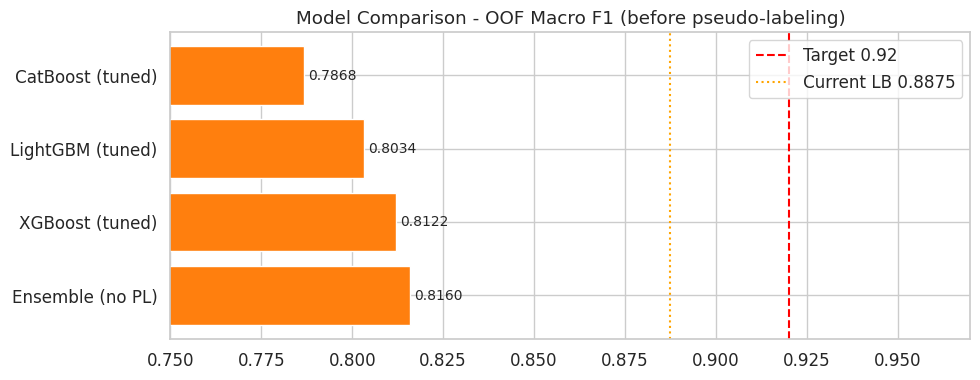

In [16]:
results = pd.DataFrame([
    ["XGBoost (tuned)",    np.mean(ll_xgb), np.mean(f1_xgb), np.mean(f1h_xgb)],
    ["LightGBM (tuned)",   np.mean(ll_lgb), np.mean(f1_lgb), np.mean(f1h_lgb)],
    ["CatBoost (tuned)",   np.mean(ll_cat), np.mean(f1_cat), np.mean(f1h_cat)],
    ["Ensemble (no PL)",   log_loss(oof_y, blend_init), -best_ef,
     f1_score(oof_y, preds_init, average=None)[2]],
], columns=["Model","LogLoss","MacroF1","HighF1"])
results = results.sort_values("MacroF1", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ca02c" if v >= 0.91 else "#1f77b4" if v >= 0.87 else "#ff7f0e"
          for v in results["MacroF1"]]
bars = ax.barh(results["Model"], results["MacroF1"], color=colors)
ax.axvline(0.92,   color="red",    ls="--", lw=1.5, label="Target 0.92")
ax.axvline(0.8875, color="orange", ls=":",  lw=1.5, label="Current LB 0.8875")
for bar, val in zip(bars, results["MacroF1"]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10)
ax.legend(); ax.set_xlim(0.75, 0.97)
ax.set_title("Model Comparison - OOF Macro F1 (before pseudo-labeling)")
plt.tight_layout(); plt.show()


## Pseudo-Labeling (2 rounds) — NEW in v3

**Why pseudo-labeling?**
The test set (2405 samples) contains unlabelled data from the same distribution.
With ~1400 high-confidence predictions we effectively add 15% more training data.
For the rare High class (only 470 train samples), adding ~60–80 confident High pseudo-labels
increases High training density by ~15%, directly improving High-F1.

**Strategy:**
- Round 1: high confidence (Low > 0.90, Medium > 0.82, High > 0.72)
- Round 2: use Round-1 models, slightly lower thresholds (Low > 0.87, Medium > 0.78, High > 0.68)
- Evaluate on **original train OOF only** (pseudo-labels have no ground truth)


In [17]:
# ── Build base models on full original train ──────────────────────────────────
_xgb_no_es = {k:v for k,v in best_xgb_params.items() if k != "early_stopping_rounds"}
_cat_no_es = {k:v for k,v in best_cat_params.items() if k != "early_stopping_rounds"}

print("Training base models (full train) for pseudo-labeling...")
xgb_base = xgb.XGBClassifier(**_xgb_no_es)
xgb_base.fit(X.values, y.values);  print("  XGB done.")

lgb_base = lgb.LGBMClassifier(**best_lgb_params)
lgb_base.fit(X, y, callbacks=[lgb.log_evaluation(-1)]);  print("  LGB done.")

cat_base = CatBoostClassifier(**_cat_no_es)
cat_base.fit(X, y, verbose=False);  print("  CAT done.")

# Ensemble predict on test
test_proba = (opt_w[0] * xgb_base.predict_proba(X_test.values) +
              opt_w[1] * lgb_base.predict_proba(X_test) +
              opt_w[2] * cat_base.predict_proba(X_test))
test_pred  = apply_thresholds(test_proba, best_t)
test_conf  = test_proba.max(axis=1)

print(f"\nTest predictions: {dict(pd.Series([v for v in test_pred]).value_counts().sort_index())}")
print(f"Confidence: min={test_conf.min():.3f}  mean={test_conf.mean():.3f}  max={test_conf.max():.3f}")


Training base models (full train) for pseudo-labeling...
  XGB done.
  LGB done.
  CAT done.

Test predictions: {0: np.int64(1722), 1: np.int64(585), 2: np.int64(98)}
Confidence: min=0.389  mean=0.885  max=0.998


In [18]:
def make_pseudo_dataset(test_pred, test_conf, thresholds):
    mask = np.array([test_conf[i] >= thresholds[test_pred[i]] for i in range(len(test_pred))])
    Xp = X_test.iloc[mask].copy()
    yp = pd.Series(test_pred[mask], index=Xp.index)
    return Xp, yp, mask

# Round 1
PL1 = {0: 0.90, 1: 0.82, 2: 0.72}
X_pl1, y_pl1, mask1 = make_pseudo_dataset(test_pred, test_conf, PL1)

print(f"Round-1 pseudo-labels: {mask1.sum()} ({100*mask1.mean():.1f}%)")
print(f"  Distribution: {dict(pd.Series(y_pl1).value_counts().sort_index())}")
print(f"  High: {(y==2).sum()} -> {(y==2).sum() + (y_pl1==2).sum()} after PL (+{(y_pl1==2).sum()})")


Round-1 pseudo-labels: 1726 (71.8%)
  Distribution: {0: np.int64(1182), 1: np.int64(466), 2: np.int64(78)}
  High: 470 -> 548 after PL (+78)


In [19]:
def oof_with_pseudo(X_pseudo, y_pseudo, fold_split=skf):
    """Retrain on (tr_fold + pseudo_test), evaluate on va_fold (original train only)."""
    oof_x = np.zeros((len(X), 3))
    oof_l = np.zeros((len(X), 3))
    oof_c = np.zeros((len(X), 3))

    for fold_i, (tr, va) in enumerate(fold_split.split(X, y)):
        Xtr_aug = pd.concat([X.iloc[tr],  X_pseudo], ignore_index=True)
        ytr_aug = pd.concat([y.iloc[tr],  y_pseudo], ignore_index=True)
        Xva, yva = X.iloc[va], y.iloc[va]

        mx = xgb.XGBClassifier(**_xgb_no_es)
        mx.fit(Xtr_aug.values, ytr_aug.values)
        oof_x[va] = mx.predict_proba(Xva.values)

        ml = lgb.LGBMClassifier(**best_lgb_params)
        ml.fit(Xtr_aug, ytr_aug, callbacks=[lgb.log_evaluation(-1)])
        oof_l[va] = ml.predict_proba(Xva)

        mc = CatBoostClassifier(**_cat_no_es)
        mc.fit(Xtr_aug, ytr_aug, verbose=False)
        oof_c[va] = mc.predict_proba(Xva)

        print(f"  Fold {fold_i+1}/5 done", end="  ")

    print()
    return oof_x, oof_l, oof_c

print("OOF with Round-1 pseudo-labels...")
oof_xgb_pl1, oof_lgb_pl1, oof_cat_pl1 = oof_with_pseudo(X_pl1, y_pl1)

print("\nOOF scores after Round-1 PL:")
for name, oof_pl in [("XGB+PL1", oof_xgb_pl1), ("LGB+PL1", oof_lgb_pl1), ("CAT+PL1", oof_cat_pl1)]:
    pred_pl = apply_thresholds(oof_pl, best_t)
    print(f"  {name}: MacroF1={f1_score(oof_y, pred_pl, average='macro'):.4f}  "
          f"HighF1={f1_score(oof_y, pred_pl, average=None)[2]:.4f}")


OOF with Round-1 pseudo-labels...
  Fold 1/5 done    Fold 2/5 done    Fold 3/5 done    Fold 4/5 done    Fold 5/5 done  

OOF scores after Round-1 PL:
  XGB+PL1: MacroF1=0.8160  HighF1=0.7388
  LGB+PL1: MacroF1=0.8101  HighF1=0.7294
  CAT+PL1: MacroF1=0.8104  HighF1=0.7258


In [20]:
# Round-2: retrain base models on train+PL1, predict test again
X_aug1 = pd.concat([X, X_pl1], ignore_index=True)
y_aug1 = pd.concat([y, y_pl1], ignore_index=True)

print("Training Round-2 base models (train + PL1)...")
xgb_r2 = xgb.XGBClassifier(**_xgb_no_es);  xgb_r2.fit(X_aug1.values, y_aug1.values)
lgb_r2 = lgb.LGBMClassifier(**best_lgb_params); lgb_r2.fit(X_aug1, y_aug1, callbacks=[lgb.log_evaluation(-1)])
cat_r2 = CatBoostClassifier(**_cat_no_es);  cat_r2.fit(X_aug1, y_aug1, verbose=False)

test_proba_r2 = (opt_w[0]*xgb_r2.predict_proba(X_test.values) +
                 opt_w[1]*lgb_r2.predict_proba(X_test) +
                 opt_w[2]*cat_r2.predict_proba(X_test))
test_pred_r2  = apply_thresholds(test_proba_r2, best_t)
test_conf_r2  = test_proba_r2.max(axis=1)

PL2 = {0: 0.87, 1: 0.78, 2: 0.68}
X_pl2, y_pl2, mask2 = make_pseudo_dataset(test_pred_r2, test_conf_r2, PL2)

# Combine both rounds (deduplicate by index)
all_pseudo_idx = np.union1d(
    np.where(mask1)[0],
    np.where(mask2)[0]
)
X_pseudo_all = X_test.iloc[all_pseudo_idx].copy()
y_pseudo_all = pd.Series(test_pred_r2[all_pseudo_idx], index=X_pseudo_all.index)

print(f"Round-2 adds {mask2.sum()} pseudo-labels ({100*mask2.mean():.1f}%)")
print(f"Combined unique: {len(all_pseudo_idx)} pseudo-labels")
print(f"Distribution: {dict(pd.Series(y_pseudo_all).value_counts().sort_index())}")
print(f"High class: {(y==2).sum()} -> {(y==2).sum() + (y_pseudo_all==2).sum()} after both PL rounds")


Training Round-2 base models (train + PL1)...
Round-2 adds 1847 pseudo-labels (76.8%)
Combined unique: 1847 pseudo-labels
Distribution: {0: np.int64(1271), 1: np.int64(494), 2: np.int64(82)}
High class: 470 -> 552 after both PL rounds


In [21]:
print("OOF with combined pseudo-labels (Round 1 + 2)...")
oof_xgb_pl, oof_lgb_pl, oof_cat_pl = oof_with_pseudo(X_pseudo_all, y_pseudo_all)

# Re-optimize ensemble weights on PL OOF
def neg_ensemble_pl(raw_w):
    w = softmax_w(raw_w)
    blended = w[0]*oof_xgb_pl + w[1]*oof_lgb_pl + w[2]*oof_cat_pl
    return -f1_score(oof_y, apply_thresholds(blended, best_t), average="macro")

best_ew_pl, best_ef_pl = None, np.inf
rng3 = np.random.default_rng(SEED + 2)
for _ in range(30):
    x0 = rng3.uniform(-1.0, 1.0, 3)
    res = minimize(neg_ensemble_pl, x0, method="Nelder-Mead", options={"maxiter": 2000})
    if res.fun < best_ef_pl:
        best_ef_pl, best_ew_pl = res.fun, res.x

opt_w_pl = softmax_w(best_ew_pl)
blend_pl = opt_w_pl[0]*oof_xgb_pl + opt_w_pl[1]*oof_lgb_pl + opt_w_pl[2]*oof_cat_pl
preds_pl = apply_thresholds(blend_pl, best_t)
f1_pl    = f1_score(oof_y, preds_pl, average="macro")

print(f"\nPL ensemble weights: XGB={opt_w_pl[0]:.3f}  LGB={opt_w_pl[1]:.3f}  CAT={opt_w_pl[2]:.3f}")
print(f"OOF MacroF1 before PL: {-best_ef:.4f}")
print(f"OOF MacroF1 after  PL: {f1_pl:.4f}  (gain: {f1_pl - (-best_ef):+.4f})")
print()
print(classification_report(oof_y, preds_pl, target_names=["Low", "Medium", "High"]))


OOF with combined pseudo-labels (Round 1 + 2)...
  Fold 1/5 done    Fold 2/5 done    Fold 3/5 done    Fold 4/5 done    Fold 5/5 done  

PL ensemble weights: XGB=0.333  LGB=0.275  CAT=0.392
OOF MacroF1 before PL: 0.8160
OOF MacroF1 after  PL: 0.8221  (gain: +0.0062)

              precision    recall  f1-score   support

         Low       0.89      0.98      0.93      6280
      Medium       0.88      0.71      0.79      2868
        High       0.86      0.66      0.75       470

    accuracy                           0.88      9618
   macro avg       0.88      0.78      0.82      9618
weighted avg       0.88      0.88      0.88      9618



In [22]:
X_aug_final = pd.concat([X, X_pseudo_all], ignore_index=True)
y_aug_final = pd.concat([y, y_pseudo_all], ignore_index=True)

print(f"Final train size: {X_aug_final.shape}  (original: {X.shape[0]}, pseudo: {len(X_pseudo_all)})")
print("Training final models on augmented dataset...")

xgb_final = xgb.XGBClassifier(**_xgb_no_es)
xgb_final.fit(X_aug_final.values, y_aug_final.values);  print("  XGB done.")

lgb_final = lgb.LGBMClassifier(**best_lgb_params)
lgb_final.fit(X_aug_final, y_aug_final, callbacks=[lgb.log_evaluation(-1)]);  print("  LGB done.")

cat_final = CatBoostClassifier(**_cat_no_es)
cat_final.fit(X_aug_final, y_aug_final, verbose=False);  print("  CAT done.")

xgb_test  = xgb_final.predict_proba(X_test.values)
lgb_test  = lgb_final.predict_proba(X_test)
cat_test  = cat_final.predict_proba(X_test)

ensemble_test = opt_w_pl[0]*xgb_test + opt_w_pl[1]*lgb_test + opt_w_pl[2]*cat_test
final_pred    = apply_thresholds(ensemble_test, best_t)
pred_labels   = [TARGET_IMAP[p] for p in final_pred]

print(f"\nTest distribution: {dict(pd.Series(pred_labels).value_counts())}")

sub_path = f"{NOTEBOOK_DIR}/submission_v3.csv"
pd.DataFrame({"ID": test_raw["ID"], TARGET: pred_labels}).to_csv(sub_path, index=False)
print(f"Saved -> {sub_path}")


Final train size: (11465, 117)  (original: 9618, pseudo: 1847)
Training final models on augmented dataset...
  XGB done.
  LGB done.
  CAT done.

Test distribution: {'Low': np.int64(1720), 'Medium': np.int64(584), 'High': np.int64(101)}
Saved -> /home/agbelgaid/Documents/WORKSPACE/Financial-Health-Prediction-Challenge/notebook/submission_v3.csv


FINAL SUMMARY
Current LB score (v2 submission):  0.8875
OOF before pseudo-labeling:        0.8160
OOF after  pseudo-labeling:        0.8221  (gain: +0.0062)


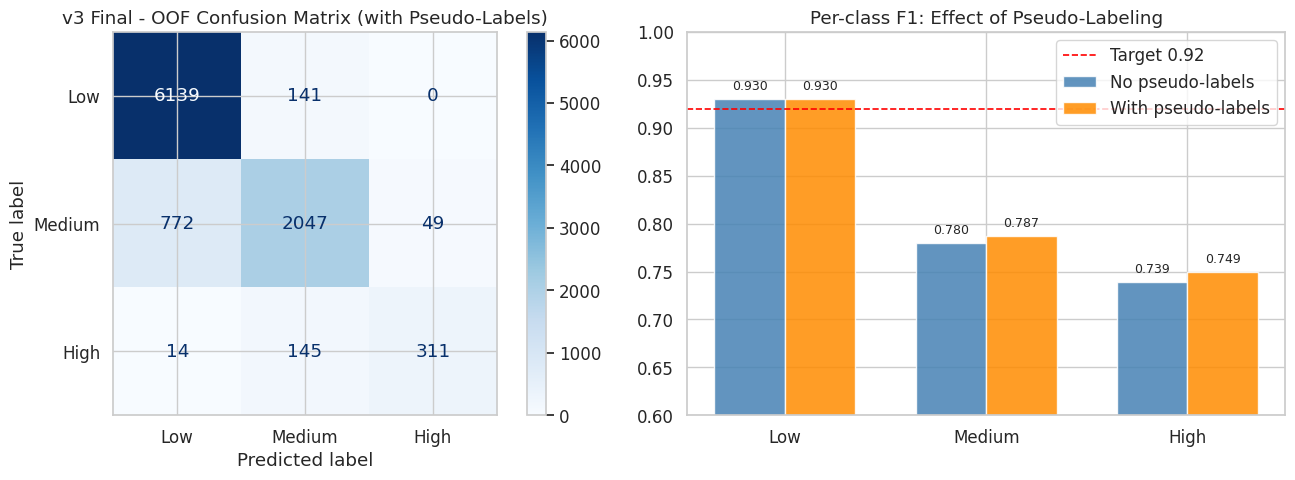

In [23]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Current LB score (v2 submission):  0.8875")
print(f"OOF before pseudo-labeling:        {-best_ef:.4f}")
print(f"OOF after  pseudo-labeling:        {f1_pl:.4f}  (gain: {f1_pl - (-best_ef):+.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(oof_y, preds_pl)
ConfusionMatrixDisplay(cm, display_labels=["Low","Medium","High"]).plot(
    ax=axes[0], cmap="Blues", colorbar=True)
axes[0].set_title("v3 Final - OOF Confusion Matrix (with Pseudo-Labels)")

classes = ["Low", "Medium", "High"]
f1_before_cls = f1_score(oof_y, preds_init, average=None)
f1_after_cls  = f1_score(oof_y, preds_pl,   average=None)
x_pos = np.arange(3); w = 0.35
axes[1].bar(x_pos - w/2, f1_before_cls, w, label="No pseudo-labels", color="steelblue",  alpha=0.85)
axes[1].bar(x_pos + w/2, f1_after_cls,  w, label="With pseudo-labels", color="darkorange", alpha=0.85)
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(classes)
axes[1].axhline(0.92, color="red", ls="--", lw=1.2, label="Target 0.92")
axes[1].set_ylim(0.6, 1.0); axes[1].legend()
axes[1].set_title("Per-class F1: Effect of Pseudo-Labeling")
for i, (b, a) in enumerate(zip(f1_before_cls, f1_after_cls)):
    axes[1].text(i - w/2, b + 0.01, f"{b:.3f}", ha="center", fontsize=9)
    axes[1].text(i + w/2, a + 0.01, f"{a:.3f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()
